## 1) Importar bibliotecas

In [1]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
import polars as pl
import numpy as np

## 2) Carregar dados

In [2]:
mnist = tf.keras.datasets.mnist

mnist = mnist.load_data()

### 2.1) Separar dados em treino e teste

In [3]:
(X_train, y_train), (X_test, y_test) = mnist

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


### 2.2) Avaliar desbalanceamento

<p>Aqui, por sorte, podemos assumir que os targets de treinamento estão balanceados.</p>

In [4]:
target_distribution_df = pl.DataFrame(data = {"target": y_train}).group_by("target").agg(
    pl.col("target").len().alias("total"),
).with_columns(
    (pl.col("total")/pl.col("total").sum()).alias("percentage")
).sort(by = "target")

target_distribution_df

target,total,percentage
u8,u32,f64
0,5923,0.098717
1,6742,0.112367
2,5958,0.0993
3,6131,0.102183
4,5842,0.097367
5,5421,0.09035
6,5918,0.098633
7,6265,0.104417
8,5851,0.097517


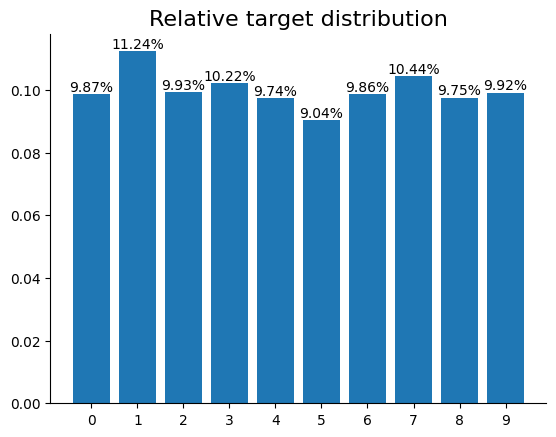

In [5]:
fig, ax = plt.subplots()

bar_plot = ax.bar(
    x = target_distribution_df["target"],
    height = target_distribution_df["percentage"],
)

ax.bar_label(
    container = bar_plot,
    labels = [
        f"{np.round(a = percentage*100, decimals = 2)}%" for percentage in target_distribution_df["percentage"]
    ],
)

ax.spines[["top", "right"]].set_visible(False)
ax.set_xticks(ticks = np.arange(0,10, 1))
ax.set_title("Relative target distribution", fontsize = 16)

plt.show()

### 2.3) Mostrando imagens

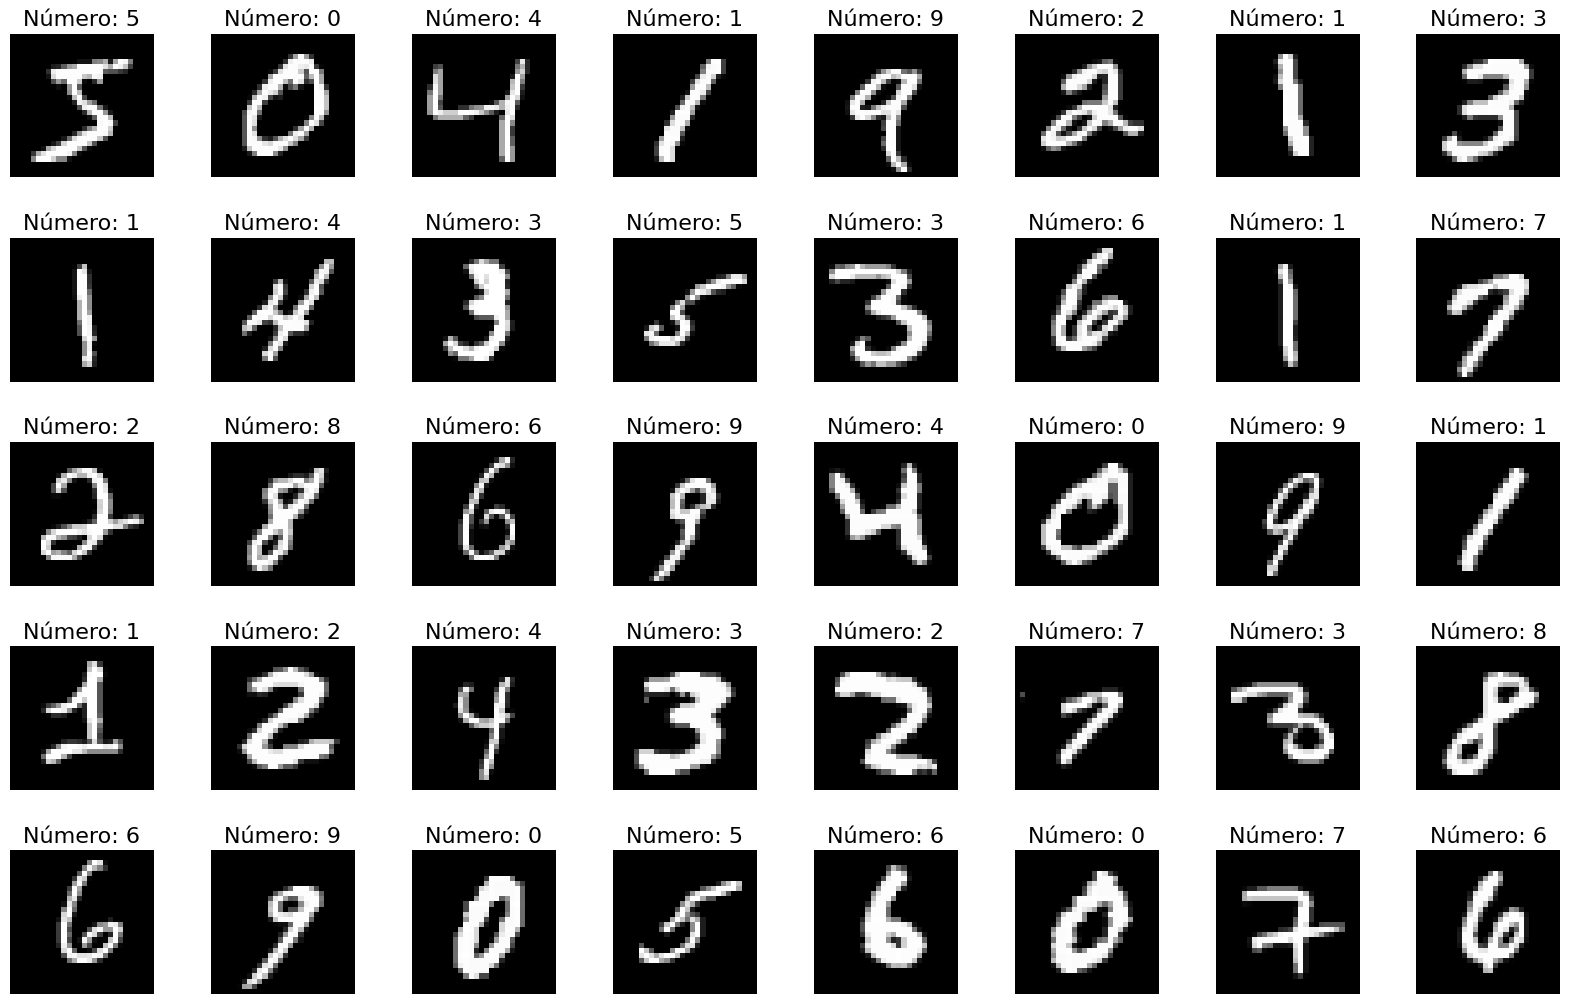

In [6]:
fig, axs = plt.subplots(
    nrows = 5,
    ncols = 8,
    figsize = (20, 12.5),
    gridspec_kw = {
        "hspace": 0.4,
        "wspace": 0.4
    }
)

for i, ax in enumerate(axs.flatten()):
    ax.imshow(X_train[i], cmap = "gray")
    ax.set_title(f"Número: {y_train[i]}", fontsize = 16)
    ax.spines[["top", "left", "bottom", "right"]].set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

### 2.4) Mostrando números detalhadamente

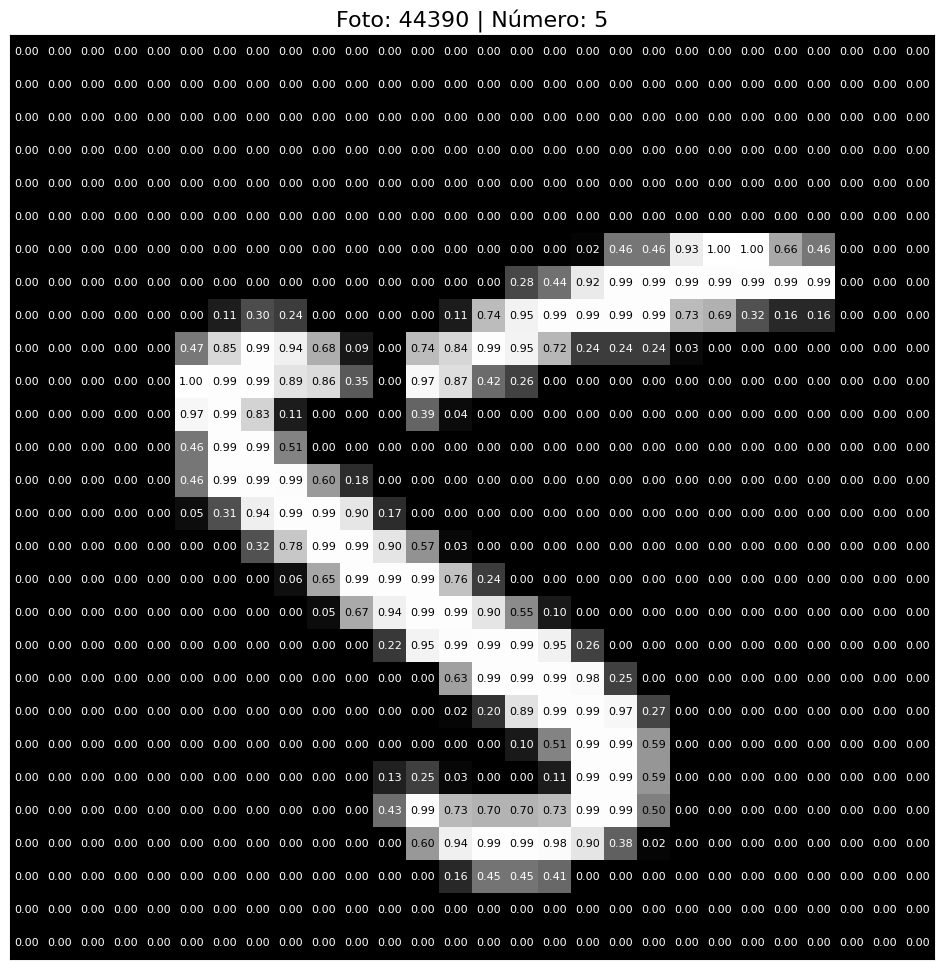

In [7]:
fig, ax = plt.subplots(
    figsize = (12, 12)
)

order = np.random.randint(low = 0, high = len(X_train))
image = X_train[order]/255

ax.imshow(
    X = image,
    cmap = "gray"
)

for y, y_axis in enumerate(image):
    for x, x_axis in enumerate(y_axis):
        value = image[y][x]
        ax.annotate(
            text = f"{value:.2f}",
            xy = (x, y),
            color = "white" if value < 0.5 else "black",
            verticalalignment = "center",
            horizontalalignment = "center",
            fontsize = 8
        )

ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"Foto: {order} | Número: {y_train[order]}", fontsize = 16)

plt.show()

## 3) Criar modelo

In [8]:
X_test.shape

(10000, 28, 28)

### 3.1) Funções de treinamento e teste:

#### 3.1.1) Criando <code>EarlyStopping</code>:

In [9]:
model_early_stopping = tf.keras.callbacks.EarlyStopping(
    min_delta = 1E-4,
    patience = 5,
    verbose = 1,
)

#### 3.1.2) Função de avaliação de treinamento <code>plot_trainning</code>:

In [10]:
def plot_trainning(
    epoch: list,
    loss: list,
    val_loss: list,
):

    fig, ax = plt.subplots()

    ax.plot(
        epoch,
        loss,
        label = "loss"
    )

    ax.plot(
        epoch,
        val_loss,
        label = "val_loss"
    )
    ax.set_title("Evolução da loss segundo treinamento.")


    plt.legend()
    plt.show()

#### 3.1.3) Função de validação: <code>plot_matrix</code>:

In [11]:
def plot_matrix(
    y_true: list[int | float],
    y_pred: list[int | float],
) -> None:
    
    fig, ax = plt.subplots()

    plot_matrix_display = ConfusionMatrixDisplay(
        confusion_matrix = confusion_matrix(
            y_true = y_true,
            y_pred = y_pred,
        ),
    )

    plot_matrix_display.plot(
        ax = ax,
    )

    plt.show()

### 3.2) Primeiro modelo:

#### 3.2.1) Definindo modelo

In [12]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(shape = (28, 28)), # Determina leitura para (28, 28)
    tf.keras.layers.Rescaling(scale = 1./255), # Multiplica valores por 1/255
    tf.keras.layers.Flatten(), # Transforma n dim array em 1 dim
    tf.keras.layers.Dense(units = 128, activation = "relu"),
    tf.keras.layers.Dropout(0.2), # Tentar evitar overfitting desligando 20% dos neurônios
    tf.keras.layers.Dense(units = 128, activation = "relu"),
    tf.keras.layers.Dropout(0.2), # Tentar evitar overfitting desligando 20% dos neurônios
    tf.keras.layers.Dense(units = 10, activation = "softmax"),
])

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1E-4),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [tf.keras.metrics.SparseCategoricalAccuracy]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,282 (462.04 KB)

 Trainable params: 118,282 (462.04 KB)

 Non-trainable params: 0 (0.00 B)

#### 3.2.2) Treinando modelo

In [13]:
history = model.fit(
    x = X_train,
    y = y_train,
    batch_size = 64,
    epochs = 100,
    shuffle = True,
    validation_split = 0.2,
    callbacks = [model_early_stopping]
)

Epoch 1/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.9802 - sparse_categorical_accuracy: 0.7114 - val_loss: 0.3699 - val_sparse_categorical_accuracy: 0.9018
Epoch 2/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4260 - sparse_categorical_accuracy: 0.8749 - val_loss: 0.2738 - val_sparse_categorical_accuracy: 0.9234
Epoch 3/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3373 - sparse_categorical_accuracy: 0.9025 - val_loss: 0.2297 - val_sparse_categorical_accuracy: 0.9353
Epoch 4/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2834 - sparse_categorical_accuracy: 0.9165 - val_loss: 0.1982 - val_sparse_categorical_accuracy: 0.9432
Epoch 5/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2519 - sparse_categorical_accuracy: 0.9263 - val_loss: 0.1773 - val_sparse_categorical_accuracy: 0.9493
Epoch 6/100
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2272 - sparse_categorical_accuracy: 0.9336 - val_loss: 0.1633 - val_sparse_categorical_accuracy: 0.952

#### 3.2.3) Avaliando qualidade do treinamento

In [14]:
total_predictions = 1000

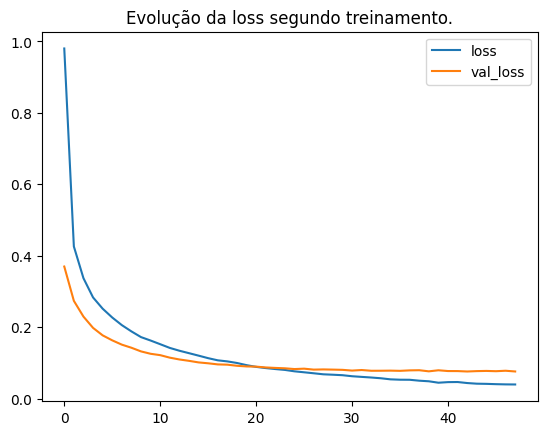

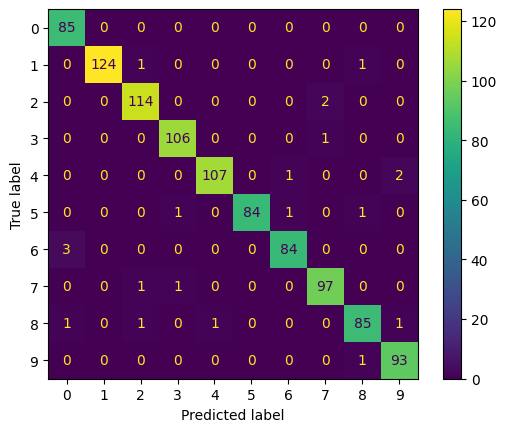

In [15]:
plot_trainning(
    epoch = history.epoch,
    loss = history.history["loss"],
    val_loss = history.history["val_loss"],
)

prediction_argmax = [
    model.predict(
        tf.expand_dims(
            input = X_test[i],
            axis = 0
        ),
        verbose = False
    ).argmax() for i in range(total_predictions)
]

plot_matrix(
    y_true = y_test[:total_predictions],
    y_pred = prediction_argmax,
)

#### 3.2.4) Avaliando minhas próprias imagens

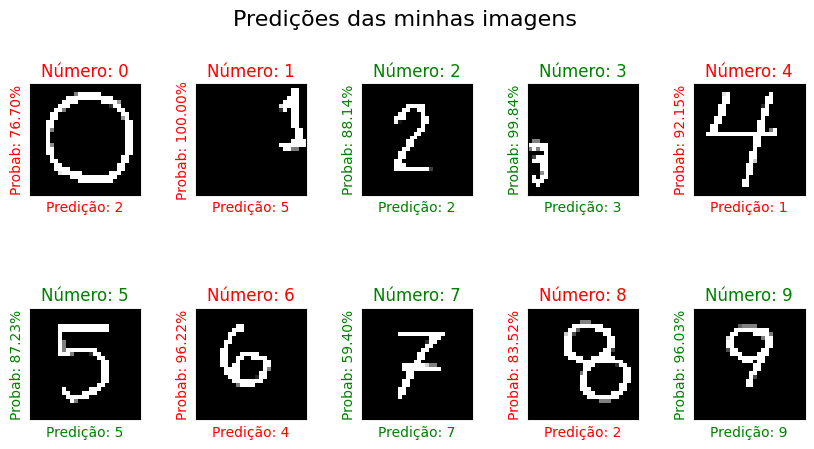

In [16]:
fig, axs = plt.subplots(
    ncols = 5, nrows = 2,
    figsize = (10, 5),
    gridspec_kw = {
        "wspace": 0.5,
        "hspace": 0.4
    }
)

axs = axs.flatten()

for i, archive in enumerate(Path("./my_images").iterdir()):

    keras_img = tf.keras.utils.load_img(
            path = archive,
            color_mode = "grayscale",
            target_size = (28, 28) # Definimos a escala em que o modelo foi treinado
        )

    img_numpy = tf.keras.utils.img_to_array(
        img = keras_img
    )

    axs[i].imshow(
        (img_numpy),
        "gray"
    )

    prediction = model.predict(
        tf.expand_dims(
            input = img_numpy,
            axis = 0
        ),
        verbose = False
    )

    color = "green" if prediction.argmax() == i else "red"

    axs[i].set_title(f"Número: {i}", color = color)
    axs[i].set_ylabel(f"Probab: {prediction.max():.2%}", color = color)
    axs[i].set_xlabel(f"Predição: {prediction.argmax()}", color = color)
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.suptitle("Predições das minhas imagens", fontsize = 16)
plt.show()